## Load libraries and model

In [1]:
import os
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision import transforms
from tqdm.notebook import tqdm

from matplotlib.colors import LinearSegmentedColormap
from src.models.train import AsparagusScoring

In [2]:
checkpoint1 = '/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/checkpoints/maskout_6/cp_epoch=39_val_loss=0.005_val_R2=0.902.ckpt'
system = AsparagusScoring.load_from_checkpoint(checkpoint1)

In [3]:
hparams = system.hparams
hparams

Namespace(alpha=0.2, augmentation='none', batch_size=16, checkpoints_path='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/checkpoints/', es_patience=21, experiment_name='asparagus_test_run', gpus=[0, 1], images_dir='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/images/', labels='data/combined/LABELS.txt', labels_file='data/combined/annotations.csv', load_checkpoint_file=None, lr=0.0001, lr_end=1e-06, maskout=True, max_epochs=500, max_grad_norm=10.0, mixup=False, mode='pad', model_hyperparams={'encoder_class': 'torchvision.models.resnet50', 'encoder_hyperparams': {'pretrained': 'imagenet'}, 'num_input': 1000, 'num_output': 1}, n_checkpoints=1, note=' resnet18 with filter images', num_workers=12, optimizer='adam', run_name='maskout_6', sampler='default', scheduler='Cosine', size=512, tracking_uri='http://qge-dev-dock-01.dev.rd.rijkzwaan.net:5000', train_names='data/combined/TRAIN.txt', val_names='data/combined/VAL.txt', weight_decay=0)

In [4]:
model = system.model

for name, param in model.named_parameters():
    print(name)

encoder.conv1.weight
encoder.bn1.weight
encoder.bn1.bias
encoder.layer1.0.conv1.weight
encoder.layer1.0.bn1.weight
encoder.layer1.0.bn1.bias
encoder.layer1.0.conv2.weight
encoder.layer1.0.bn2.weight
encoder.layer1.0.bn2.bias
encoder.layer1.0.conv3.weight
encoder.layer1.0.bn3.weight
encoder.layer1.0.bn3.bias
encoder.layer1.0.downsample.0.weight
encoder.layer1.0.downsample.1.weight
encoder.layer1.0.downsample.1.bias
encoder.layer1.1.conv1.weight
encoder.layer1.1.bn1.weight
encoder.layer1.1.bn1.bias
encoder.layer1.1.conv2.weight
encoder.layer1.1.bn2.weight
encoder.layer1.1.bn2.bias
encoder.layer1.1.conv3.weight
encoder.layer1.1.bn3.weight
encoder.layer1.1.bn3.bias
encoder.layer1.2.conv1.weight
encoder.layer1.2.bn1.weight
encoder.layer1.2.bn1.bias
encoder.layer1.2.conv2.weight
encoder.layer1.2.bn2.weight
encoder.layer1.2.bn2.bias
encoder.layer1.2.conv3.weight
encoder.layer1.2.bn3.weight
encoder.layer1.2.bn3.bias
encoder.layer2.0.conv1.weight
encoder.layer2.0.bn1.weight
encoder.layer2.0.bn1

In [5]:
device = torch.device('cuda:0')
system.freeze()

## load dataset and sample image

In [6]:
from src.data.datasets import Scoring, ScoringTest

names = np.loadtxt('/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/splits/VAL.txt', dtype=str)
dataset = Scoring(names=names,
                  labels_file='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/annotations.csv',
                  size=hparams.size,
                  mode=hparams.mode,
                  images_dir='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/images/',
                  maskout=hparams.maskout)

In [7]:
img, score = dataset[40]
print(img.shape)

torch.Size([3, 512, 512])


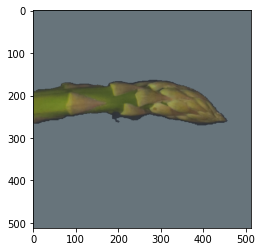

In [8]:
mean=(0.485, 0.456, 0.406)
std=(0.229, 0.224, 0.225)
img1 = np.moveaxis(img.numpy(), 0, -1)
img1 = 255*(img1 * std + mean)
img1 = img1[:, :, ::-1].astype(int)
plt.imshow(img1)

In [9]:
normalize = transforms.Normalize(
                    mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)
                                            )
norm_img = normalize(img)

In [10]:
input_img = norm_img.unsqueeze(0)
print(input_img.shape)

torch.Size([1, 3, 512, 512])


In [11]:
# Prediction output
pred = system(input_img)
pred

tensor([[1.0000]])

In [12]:
default_cmap = LinearSegmentedColormap.from_list('custom blue', 
                                                 [(0, '#ffffff'),
                                                  (0.25, '#000000'),
                                                  (1, '#000000')])

# TorchRay

https://github.com/facebookresearch/TorchRay/blob/master/docs/attribution.rst

From available TorchRay methods, we will implement the following methods:

* Backpropagation methods

  * Gradient [1]_ (:mod:`.gradient`) 
  * Deconvolution (:mod:`.deconvnet`)
  * Guided backpropagation (:mod:`.guided_backprop`)
  * Grad-CAM (:mod:`.grad_cam`)

# Gradient 

In [14]:
from torchray.benchmark import plot_example

In [19]:
from torchray.attribution.gradient import gradient

# Gradient method.
saliency = gradient(model, input_img, pred)

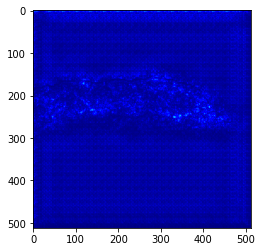

In [21]:
plt.imshow(saliency.detach().cpu()[0][0], cmap='jet')

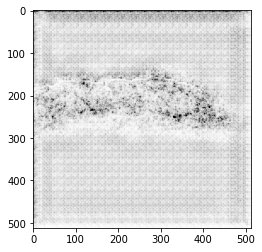

In [22]:
plt.imshow(saliency.detach().cpu()[0][0], cmap=default_cmap)

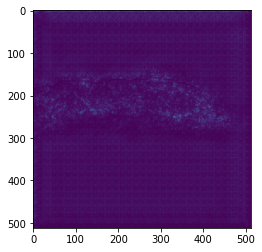

In [23]:
plt.imshow(saliency.detach().cpu()[0][0])

# Deconvolution

In [24]:
from torchray.attribution.deconvnet import deconvnet

# DeConvNet method.
deconv = deconvnet(model, input_img, pred)

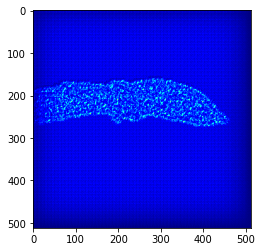

In [25]:
plt.imshow(deconv.detach().cpu()[0][0], cmap='jet')

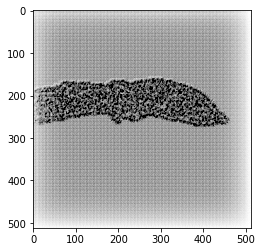

In [27]:
plt.imshow(deconv.detach().cpu()[0][0], cmap=default_cmap)

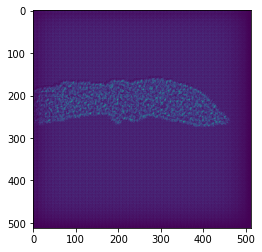

In [28]:
plt.imshow(deconv.detach().cpu()[0][0])

In [38]:
guided_bp.shape

torch.Size([1, 1, 512, 512])

setting threshold to remove noises
Have i done any step to sharp original image, how the output of attribution method can be different?
What i have tried, why did not it work and how can it be improved? 



# Guided Backpropagation

In [29]:
from torchray.attribution.guided_backprop import guided_backprop

# Guided backprop.
guided_bp = guided_backprop(model, input_img, pred)

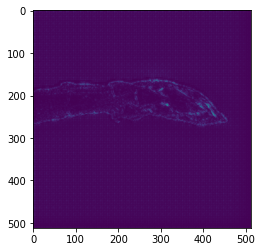

In [30]:
plt.imshow(guided_bp.detach().cpu()[0][0])

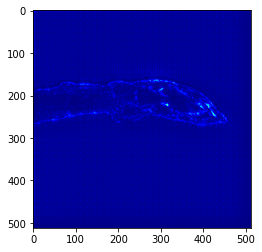

In [31]:
plt.imshow(guided_bp.detach().cpu()[0][0], cmap='jet')

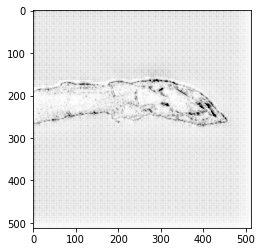

In [32]:
plt.imshow(guided_bp.detach().cpu()[0][0], cmap=default_cmap)

In [37]:
guided_bp.shape

torch.Size([1, 1, 512, 512])

# Grad-CAM

source code: https://github.com/facebookresearch/TorchRay/blob/master/examples/grad_cam.py

In [33]:
from torchray.attribution.grad_cam import grad_cam

# Grad-CAM for layer 1
gcam_bp = grad_cam(model, input_img, pred, saliency_layer='encoder.layer1')

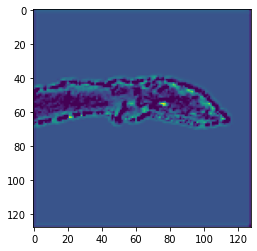

In [34]:
plt.imshow(gcam_bp.detach().cpu()[0][0])

In [44]:
gcam_bp.shape

torch.Size([1, 1, 128, 128])

In [64]:
resize = transforms.Resize((512,512))
bp = resize(gcam_bp)
bp.shape

torch.Size([1, 1, 512, 512])

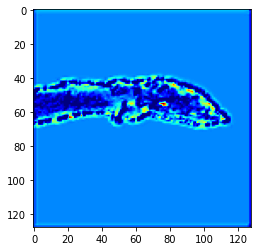

In [65]:
plt.imshow(gcam_bp.detach().cpu()[0][0], cmap='jet')

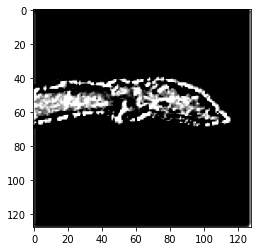

In [66]:
plt.imshow(gcam_bp.detach().cpu()[0][0], cmap=default_cmap)

In [67]:
# Grad-CAM for layer 2 
gcam_bp = grad_cam(model, input_img, pred, saliency_layer='encoder.layer2')

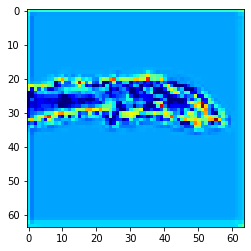

In [68]:
bp = resize(gcam_bp)

plt.imshow(gcam_bp.detach().cpu()[0][0], cmap='jet')

In [69]:
# Grad-CAM for layer 3 
gcam_bp = grad_cam(model, input_img, pred, saliency_layer='encoder.layer3')

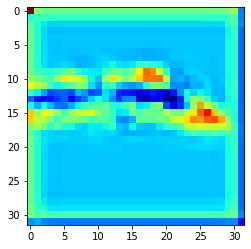

In [70]:
bp = resize(gcam_bp)

plt.imshow(gcam_bp.detach().cpu()[0][0], cmap='jet')